In [1]:
import pandas as pd

In [4]:
result = pd.read_csv('../data/Final Sales.csv')
result['Date'] = pd.to_datetime(result['Date'])

/var/folders/vg/pxkxmzld5s73d47lq0mx8hyr0000gn/T/ipykernel_34613/3634394403.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  result = pd.read_csv('../data/Final Sales.csv')


In [8]:
rem = result[result['Date']>= '2024-04-01'].groupby(['Branch', result['Date'].dt.to_period('M').dt.to_timestamp().rename('MonthStart')]).agg({'Sales Qty.': 'sum'}).reset_index()

In [15]:
rem.groupby('MonthStart').agg({'Sales Qty.': 'sum'})

,Sales Qty.
MonthStart,
2024-04-01,100783.0
2024-05-01,52367.0
2024-06-01,19375.0
2024-07-01,13306.0
2024-08-01,22619.0
2024-09-01,29124.0
2024-10-01,23307.0
2024-11-01,18074.0
2024-12-01,68731.0


In [11]:
main_df = pd.read_csv('../data/main_df.csv')
main_df['Date'] = pd.to_datetime(main_df['Date'])

In [57]:
import pandas as pd

# load your csv into df; ensure Date parsed as datetime
# df = pd.read_csv('yourfile.csv', parse_dates=['Date'])

# Example variable: df with columns ['Date','Branch','Qty']
main_df['Year'] = main_df['Date'].dt.year
main_df['Month'] = main_df['Date'].dt.month

# 1) company totals by year-month
company = main_df.groupby(['Year','Month'])['Qty'].sum().reset_index(name='CompanyTotal')

# restrict years for seasonality calculation
years = [2019, 2020, 2021, 2022, 2023, 2024]
season = company[company['Year'].isin(years)]

# 2) average total per calendar month across the selected years
avg_by_month = season.groupby('Month')['CompanyTotal'].mean().rename('AvgTotal').reset_index()

# 3) average March total
avg_march = avg_by_month.loc[avg_by_month['Month']==3, 'AvgTotal'].iloc[0]

# 4) seasonality index
avg_by_month['SI'] = avg_by_month['AvgTotal'] / avg_march

# 5) anchor (actual total in March 2024)
anchor = company[(company['Year']==2024) & (company['Month']==3)]['CompanyTotal'].iloc[0]  # should be 76810.5

# 6) company forecasts Apr2024-Mar2025
months = list(range(4,13)) + list(range(1,4))  # Apr..Dec then Jan..Mar
forecast_company = []
for m in months:
    si = avg_by_month.loc[avg_by_month['Month']==m, 'SI'].iloc[0]
    forecast_company.append({'Month': m, 'ForecastCompany': anchor * si})

fc_company_df = pd.DataFrame(forecast_company)

# 7) branch shares from March-2024
march2024 = main_df[(main_df['Year']==2024) & (main_df['Month']==3)].groupby('Branch')['Qty'].sum()
march_total = march2024.sum()
shares = (march2024 / march_total).rename('Share').reset_index()

# 8) expand company forecast to branches
fc_company_df = fc_company_df.assign(key=1)
shares = shares.assign(key=1)
fc_branches = fc_company_df.merge(shares, on='key').drop(columns='key')
fc_branches['ForecastBranch'] = fc_branches['ForecastCompany'] * fc_branches['Share']

# round if needed
fc_branches['ForecastBranch'] = fc_branches['ForecastBranch'].round(0)
fc_company_df['ForecastCompany'] = fc_company_df['ForecastCompany'].round(0)


In [58]:
avg_by_month

,Month,AvgTotal,SI
0,1,18985.800,0.503246
1,2,33274.200,0.881980
2,3,37726.700,1.000000
3,4,39218.375,1.039539
4,5,21182.300,0.561467
5,6,13506.000,0.357996
6,7,9532.400,0.252670
7,8,11785.900,0.312402
8,9,15548.100,0.412125
9,10,13158.000,0.348772


In [60]:
fc_company_df['ForecastCompany'].sum()

np.float64(534817.0)

In [41]:
tall = (rem.groupby('MonthStart').agg({'Sales Qty.': 'sum'}).reset_index())
tall.rename(columns={'MonthStart': 'Date'}, inplace=True)
tall['Date'] = pd.to_datetime(tall['Date'])
tall['Forecast Sales'] = fc_company_df['ForecastCompany']

In [42]:
tall.rename(columns={'Sales Qty.': 'Actual Sales'}, inplace=True)

In [44]:
# Branch-level seasonality and forecasts (Apr 2024 - Mar 2025)
# Ensures per-branch seasonality rather than company-level share expansion

# Ensure derived columns exist
if 'Year' not in main_df.columns or 'Month' not in main_df.columns:
    main_df['Year'] = main_df['Date'].dt.year
    main_df['Month'] = main_df['Date'].dt.month

# Monthly totals per branch-year-month
branch_month_totals = (
    main_df.groupby(['Branch', 'Year', 'Month'])['Qty']
    .sum()
    .reset_index(name='BranchTotal')
)

# Seasonality from historical years (per branch)
years = [2021, 2022, 2023]
season_b = branch_month_totals[branch_month_totals['Year'].isin(years)]
avg_by_month_branch = (
    season_b.groupby(['Branch', 'Month'])['BranchTotal']
    .mean()
    .rename('AvgTotal')
    .reset_index()
)

# Seasonality index per branch: SI = Avg(month)/Avg(March)
march_avg = (
    avg_by_month_branch[avg_by_month_branch['Month'] == 3][['Branch', 'AvgTotal']]
    .rename(columns={'AvgTotal': 'AvgMarch'})
)
si_branch = avg_by_month_branch.merge(march_avg, on='Branch', how='left')
si_branch['SI'] = si_branch['AvgTotal'] / si_branch['AvgMarch']
si_branch = si_branch[['Branch', 'Month', 'SI']]

# Anchor per branch: actual March-2024 totals
anchor_branch = (
    branch_month_totals[
        (branch_month_totals['Year'] == 2024) & (branch_month_totals['Month'] == 3)
    ][['Branch', 'BranchTotal']]
    .rename(columns={'BranchTotal': 'Anchor'})
)

# Forecast months Apr..Dec 2024, Jan..Mar 2025
months = list(range(4, 13)) + list(range(1, 4))
grid = (
    anchor_branch[['Branch']]
    .assign(key=1)
    .merge(pd.DataFrame({'Month': months, 'key': 1}), on='key')
    .drop(columns='key')
)

# Combine SI and anchors to compute branch forecasts
fc = (
    grid.merge(si_branch, on=['Branch', 'Month'], how='left')
        .merge(anchor_branch, on='Branch', how='left')
)
fc['ForecastBranch'] = (fc['Anchor'] * fc['SI']).round(0)

# Add Year and Date for timeline
fc['Year'] = fc['Month'].apply(lambda m: 2024 if m >= 4 else 2025)
fc['Date'] = pd.to_datetime(dict(year=fc['Year'], month=fc['Month'], day=1))

# Final per-branch forecast table (overwrites earlier company-share expansion)
fc_branches = (
    fc[['Branch', 'Year', 'Month', 'Date', 'ForecastBranch']]
    .sort_values(['Branch', 'Year', 'Month'])
    .reset_index(drop=True)
)

# Preview
fc_branches.head()


,Branch,Year,Month,Date,ForecastBranch
0,BLR,2024,4,2024-04-01,4800.0
1,BLR,2024,5,2024-05-01,3403.0
2,BLR,2024,6,2024-06-01,2462.0
3,BLR,2024,7,2024-07-01,2214.0
4,BLR,2024,8,2024-08-01,2554.0


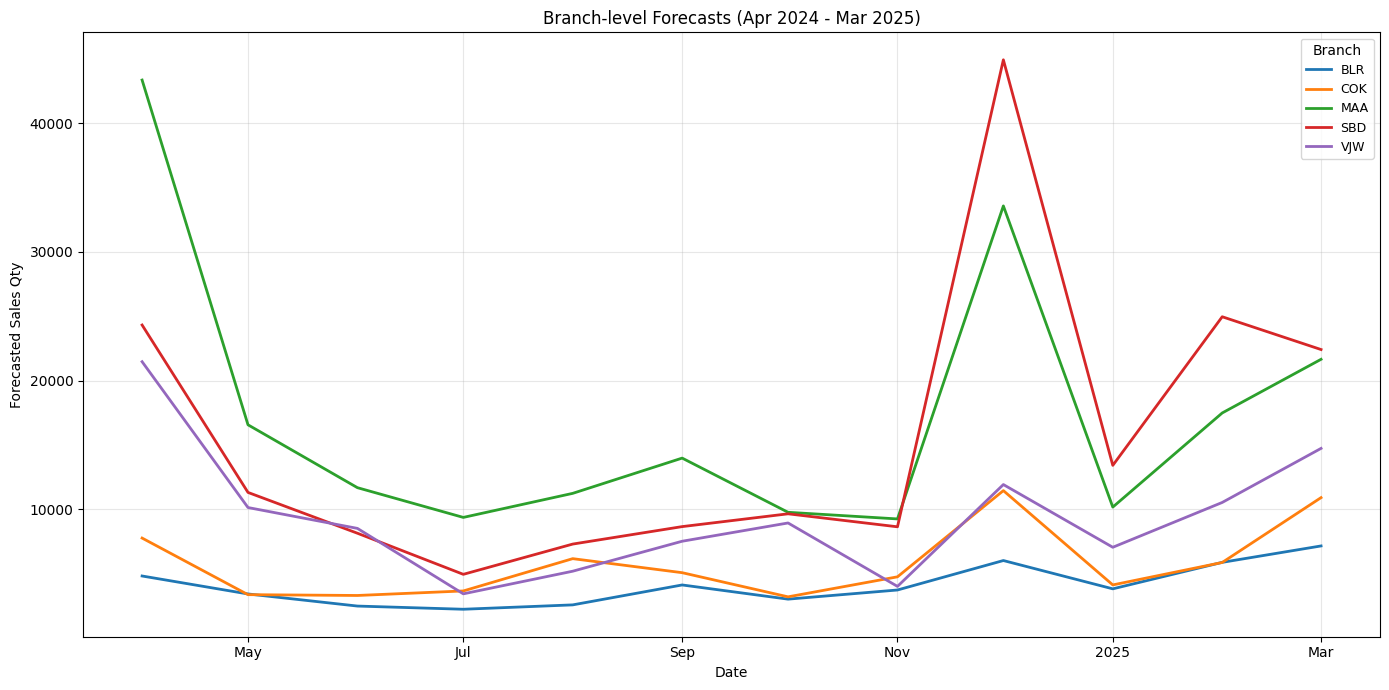

In [45]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Validate expected columns
req = {'Branch', 'Date', 'ForecastBranch'}
missing = req - set(fc_branches.columns)
if missing:
    raise ValueError(f"Missing columns in fc_branches: {missing}")

plot_df = fc_branches.copy()
plot_df['Date'] = pd.to_datetime(plot_df['Date'])
plot_df = plot_df.sort_values(['Branch', 'Date'])

plt.figure(figsize=(14, 7))
for branch, g in plot_df.groupby('Branch'):
    plt.plot(g['Date'], g['ForecastBranch'], label=str(branch), linewidth=2)

plt.title('Branch-level Forecasts (Apr 2024 - Mar 2025)')
plt.xlabel('Date')
plt.ylabel('Forecasted Sales Qty')
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

# If too many branches, limit legend columns for readability
n_branches = plot_df['Branch'].nunique()
legend_cols = 1 if n_branches <= 10 else 2 if n_branches <= 20 else 3
plt.legend(title='Branch', ncol=legend_cols, fontsize=9)
plt.tight_layout()
plt.show()


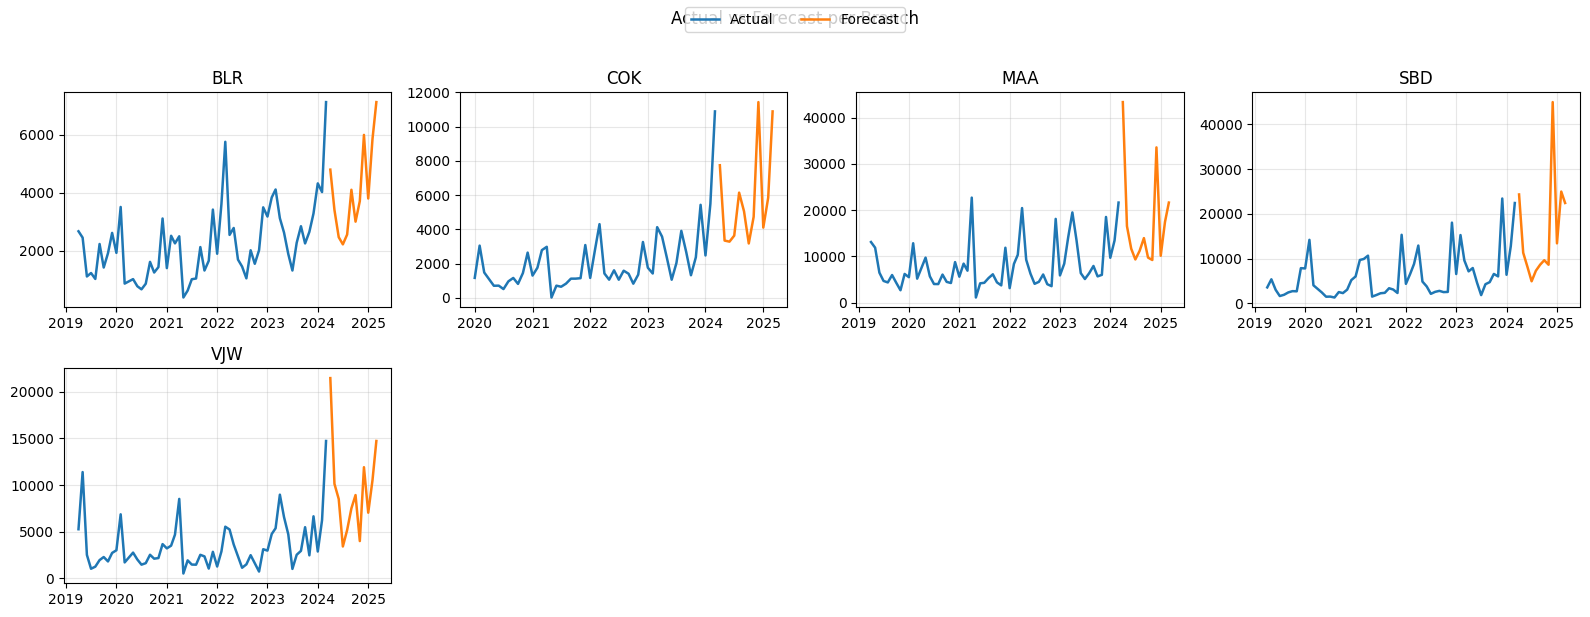

In [47]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import numpy as np

# Prepare monthly actuals per branch aligned to month start
if 'Date' not in main_df.columns:
    raise ValueError('main_df must contain Date column')

actuals = (
    main_df.assign(Date=pd.to_datetime(main_df['Date']))
           .groupby(['Branch', pd.Grouper(key='Date', freq='MS')])['Qty']
           .sum()
           .reset_index(name='Actual')
)

# Align forecast with actuals by Branch + Date
fc = fc_branches[['Branch', 'Date', 'ForecastBranch']].copy()
fc['Date'] = pd.to_datetime(fc['Date'])

merged = actuals.merge(fc, on=['Branch', 'Date'], how='outer')
merged = merged.sort_values(['Branch', 'Date'])

# Plot small multiples, one panel per branch
branches = merged['Branch'].dropna().unique()
num_branches = len(branches)
if num_branches == 0:
    raise ValueError('No branches found to plot')

ncols = 4
nrows = math.ceil(num_branches / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 3*nrows), sharex=False, sharey=False)
axes = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

for i, br in enumerate(branches):
    ax = axes[i]
    g = merged[merged['Branch'] == br]
    g = g.sort_values('Date')
    # Plot Actuals
    ax.plot(g['Date'], g['Actual'], label='Actual', color='tab:blue', linewidth=1.8)
    # Plot Forecasts
    ax.plot(g['Date'], g['ForecastBranch'], label='Forecast', color='tab:orange', linewidth=1.8)
    ax.set_title(str(br))
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

# Hide any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
fig.suptitle('Actual vs Forecast per Branch', y=1.02)
fig.tight_layout()
plt.show()


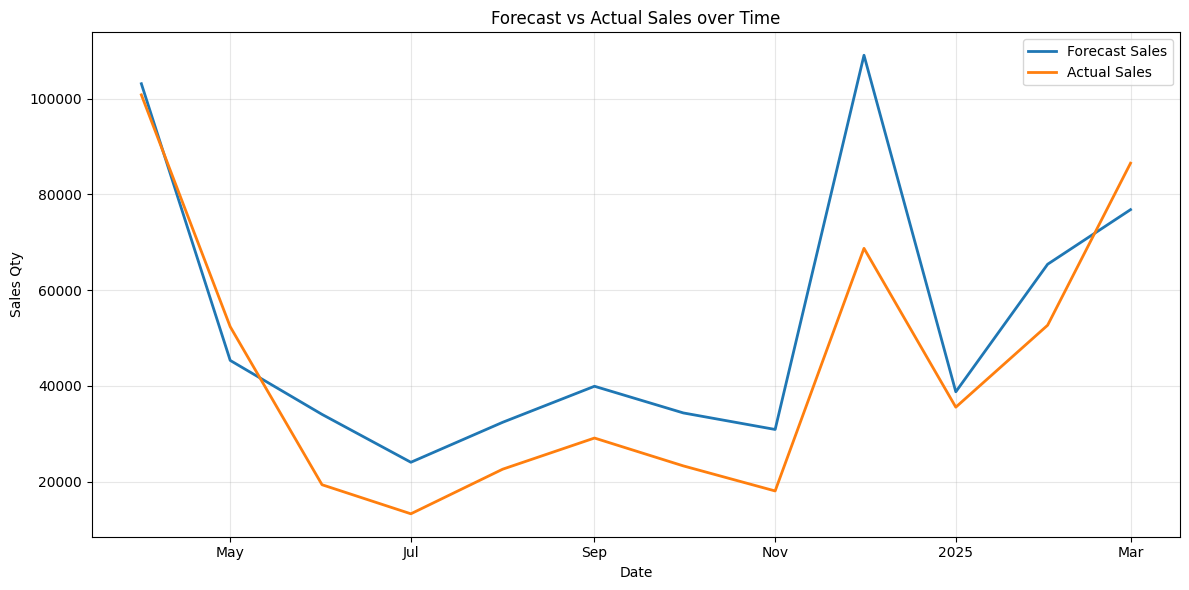

In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure proper dtypes
if 'Date' in tall.columns:
    tall['Date'] = pd.to_datetime(tall['Date'])

# Sort for clean plotting
plot_df = tall[tall['Date'] < '2025-04-01'].sort_values('Date').copy()

# Basic validation
required_cols = {'Date', 'Forecast Sales', 'Actual Sales'}
missing = required_cols - set(plot_df.columns)
if missing:
    raise ValueError(f"Missing required columns in tall: {missing}")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(plot_df['Date'], plot_df['Forecast Sales'], label='Forecast Sales', linewidth=2)
plt.plot(plot_df['Date'], plot_df['Actual Sales'], label='Actual Sales', linewidth=2)

# Formatting
plt.title('Forecast vs Actual Sales over Time')
plt.xlabel('Date')
plt.ylabel('Sales Qty')
plt.legend()
plt.grid(True, alpha=0.3)

# Nice monthly ticks if dates present
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.tight_layout()
plt.show()


In [49]:
gatwik = result[result['Date']>= '2024-04-01'].groupby(['Branch', result['Date'].dt.to_period('M').dt.to_timestamp().rename('MonthStart')]).agg({'Sales Qty.': 'sum'}).reset_index()

In [51]:
mapped_branches = {
    'CHENNAI': 'MAA',
    'BANGALORE': 'BLR',
    'HYDERABAD': 'SDB',
    "COCHIN": "COK",
    "VIJAYAWADA": "VJW"
    }
gatwik['Branch'] = gatwik['Branch'].apply(lambda x: mapped_branches[x])

In [65]:
test = result.groupby([result['Date'].dt.to_period('M').dt.to_timestamp().rename('MonthStart')]).agg({'Sales Qty.': 'sum'}).reset_index()

In [67]:
test.rename(columns={'MonthStart': 'Date'}, inplace=True)
test['Date'] = pd.to_datetime(test['Date'])
test


,Date,Sales Qty.
0,2021-11-01,144.5
1,2021-12-01,1.0
2,2022-01-01,6250.0
3,2022-02-01,23036.0
4,2022-03-01,34072.0
5,2022-04-01,41698.0
6,2022-05-01,20794.0
7,2022-06-01,13903.5
8,2022-07-01,9544.0
9,2022-08-01,11086.5


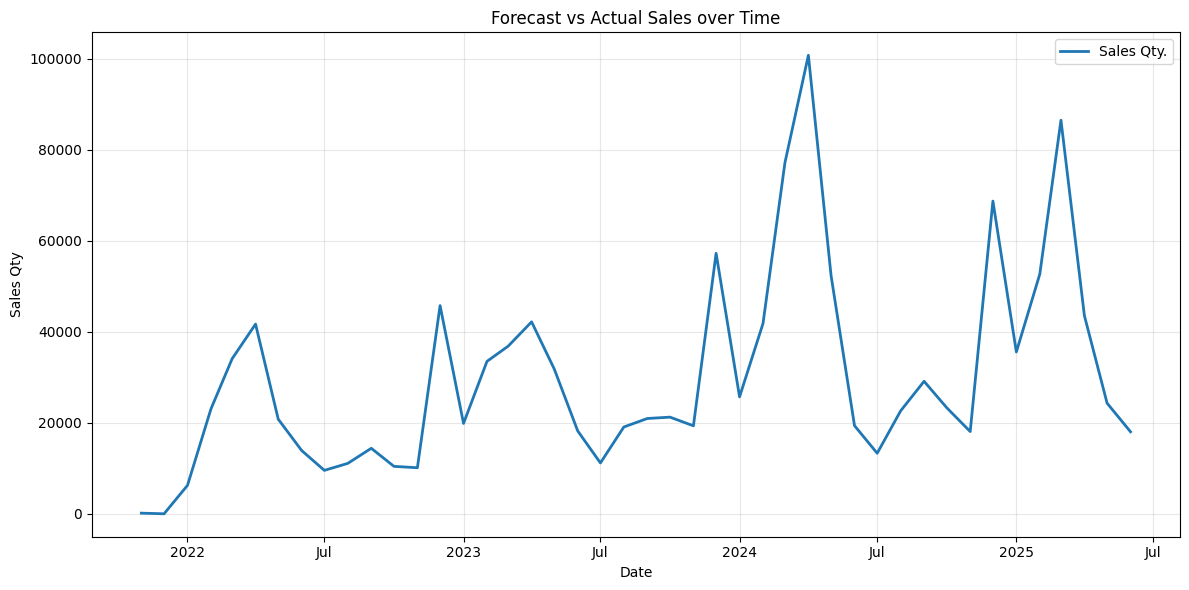

In [68]:
# Sort for clean plotting
plot_df = test[test['Date'] > '2020-01-01'].sort_values('Date').copy()

# Basic validation
required_cols = {'Date', 'Sales Qty.'}
missing = required_cols - set(plot_df.columns)
if missing:
    raise ValueError(f"Missing required columns in tall: {missing}")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(plot_df['Date'], plot_df['Sales Qty.'], label='Sales Qty.', linewidth=2)

# Formatting
plt.title('Forecast vs Actual Sales over Time')
plt.xlabel('Date')
plt.ylabel('Sales Qty')
plt.legend()
plt.grid(True, alpha=0.3)

# Nice monthly ticks if dates present
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.tight_layout()
plt.show()
